In [ ]:
!pip install grad-cam

Configuration

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from google.colab import drive
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 32
epochs = 50
lr = 1e-3

Device: cuda


Connect Drive to locate output

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
print(os.listdir("/content/drive"))
os.makedirs("/content/drive/MyDrive/ViT-models", exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']


ViT-based Architecture

In [ ]:
# Patch Embedding
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=256):
        super().__init__()

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)        # (B, embed_dim, H', W')
        x = x.flatten(2)        # (B, embed_dim, N)
        x = x.transpose(1, 2)   # (B, N, embed_dim)
        return x
# Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
      x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
      x = x + self.mlp(self.norm2(x))
      return x

#ViT model
class ViT(nn.Module):
  def __init__(self,img_size=224, patch_size=16,num_classes=10, embed_dim=256, depth=6, num_heads=8):
    super().__init__()
    self.patch_embedding = PatchEmbedding(
    img_size=img_size,
    patch_size=patch_size,
    in_channels=3,
    embed_dim=embed_dim
    )
    num_patches = (img_size // patch_size) ** 2
    self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
    self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
    self.transformer = nn.Sequential(
        *[TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(embed_dim),
        nn.Linear(embed_dim, num_classes)
    )

  def forward(self, x):
    x = self.patch_embedding(x)
    B = x.shape[0]
    cls_tokens = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)
    x = x + self.pos_embedding
    x = self.transformer(x)
    x = x[:, 0]
    x = self.mlp_head(x)
    return x

Load dataset

In [ ]:


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

Train code

In [ ]:
#Training
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)   # logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return total_loss / len(loader), acc

#Evaluation
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

Model Setup

In [ ]:
model = ViT(num_classes=10,patch_size = 8, embed_dim=128, num_heads= 8 ).to(device)
print(model)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)

ViT(
  (patch_embedding): PatchEmbedding(
    (proj): Conv2d(3, 128, kernel_size=(8, 8), stride=(8, 8))
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
 

Training Phase

In [ ]:


# ===== MOUNT DRIVE =====
if not os.path.exists("/content/drive"):
    from google.colab import drive
    drive.mount('/content/drive')

os.makedirs("/content/drive/MyDrive/models", exist_ok=True)

checkpoint_path = "/content/drive/MyDrive/ViT-models/checkpoint.pth"
best_model_path = "/content/drive/MyDrive/ViT-models/best_model.pth"

# ===== RESUME =====
start_epoch = 0
best_acc = 0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']

    print(f"Resume from epoch {start_epoch}, best_acc={best_acc:.4f}")

# TRAIN
start_time = time.time()

for epoch in range(start_epoch, epochs):
    epoch_start = time.time()
    model.train()
    total_loss, correct, total = 0, 0, 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)


        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct/total:.4f}"
        })

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # TEST
    model.eval()
    correct, total = 0, 0

    test_bar = tqdm(test_loader, desc=f"Epoch {epoch+1} [Test]")

    with torch.no_grad():
        for images, labels in test_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            test_bar.set_postfix({
                "acc": f"{correct/total:.4f}"
            })

    test_acc = correct / total

    epoch_time = time.time() - epoch_start
    total_time = time.time() - start_time
    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Acc: {test_acc:.4f}")
    print(f"Epoch Time: {epoch_time:.2f}s | Total Time: {total_time/60:.2f} min")
    print("-" * 50)

    # SAVE BEST
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), best_model_path)
        print("Saved BEST model!")

    # SAVE CHECKPOINT
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc
    }, checkpoint_path)

Resume from epoch 50, best_acc=0.9082


Testing Phase

In [ ]:

all_preds = []
all_labels = []
wrong_images = []
wrong_true = []
wrong_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)          # logits
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        mask = preds != labels

        wrong_images.extend(images[mask].cpu())
        wrong_true.extend(labels[mask].cpu())
        wrong_pred.extend(preds[mask].cpu())


acc = accuracy_score(all_labels, all_preds)
print("Accuracy:", acc)



precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro"
)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print(classification_report(all_labels, all_preds))

Accuracy: 0.9064
Precision: 0.9068908224257445
Recall: 0.9064
F1-score: 0.9054234980686825
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1000
           1       0.98      0.99      0.98      1000
           2       0.85      0.89      0.87      1000
           3       0.88      0.93      0.90      1000
           4       0.86      0.84      0.85      1000
           5       0.98      0.96      0.97      1000
           6       0.82      0.69      0.75      1000
           7       0.89      0.99      0.94      1000
           8       0.98      0.97      0.98      1000
           9       0.99      0.90      0.94      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



Confusion Matrix

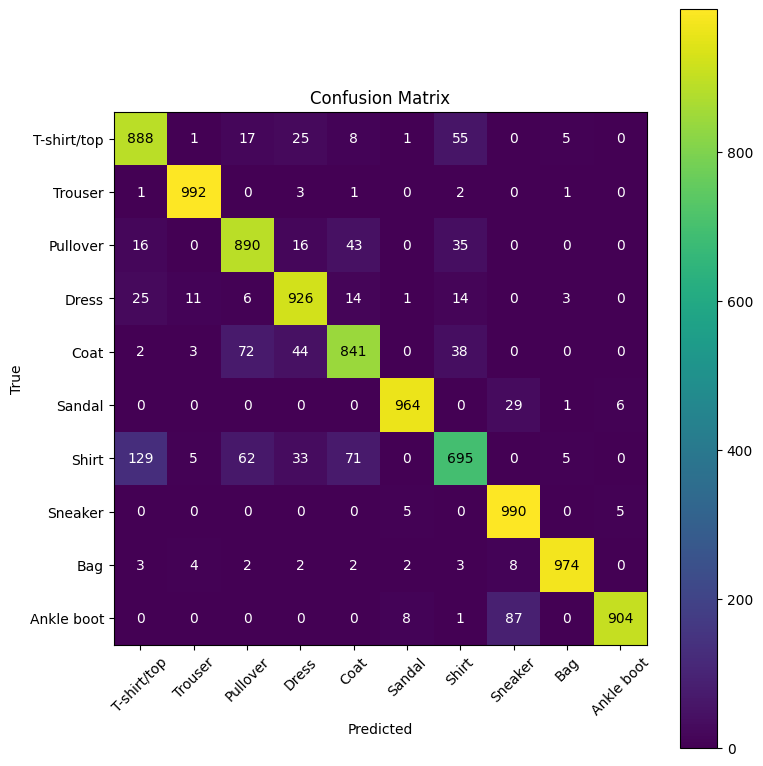

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = train_dataset.classes

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black" if cm[i, j] > cm.max()/2 else "white")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

Wrong Image

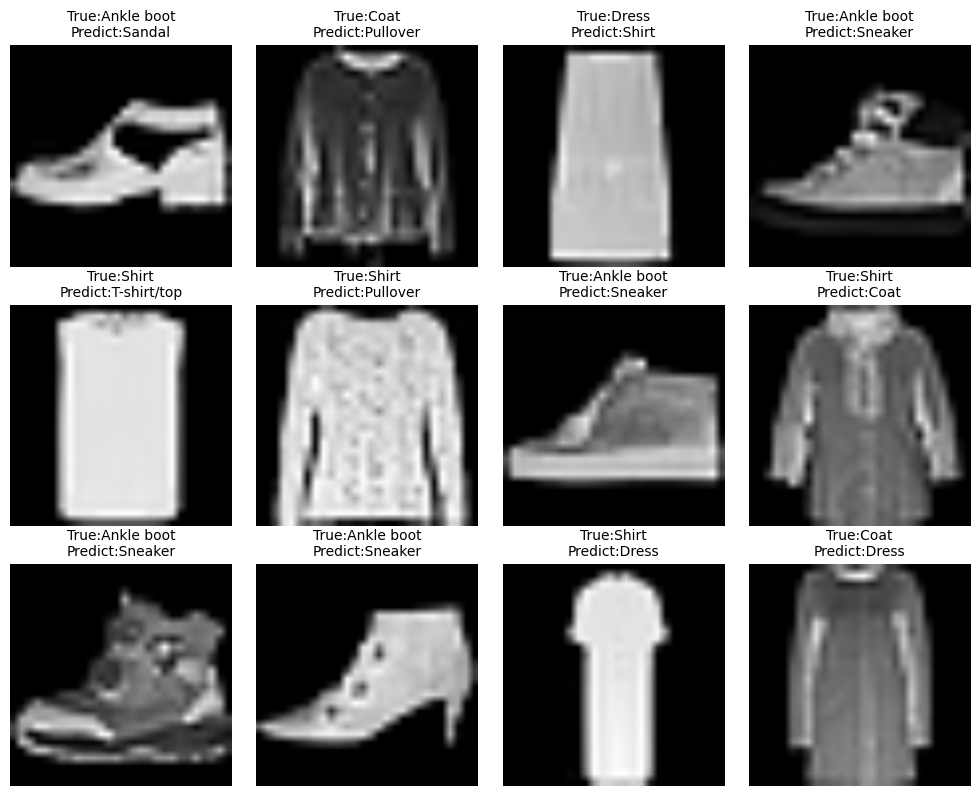

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

classes = train_dataset.classes
num_show = min(12, len(wrong_images))

for i in range(num_show):
    img = wrong_images[i].permute(1, 2, 0).cpu().numpy()

    mean = np.array([0.5] * img.shape[2])
    std = np.array([0.5] * img.shape[2])
    img = img * std + mean
    img = np.clip(img, 0, 1)

    ax = axes[i // 4, i % 4]

    if img.shape[2] == 1:
        img = img.squeeze()
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(img)
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_pred[i]]

    ax.set_title(f"True:{true_label}\nPredict:{pred_label}", fontsize=10)
    ax.axis("off")

for j in range(num_show, 12):
    axes[j // 4, j % 4].axis("off")

plt.tight_layout()
plt.show()

Interpretability

In [ ]:

# model.eval()


# target_layer = model.transformer[-1]

# cam = GradCAM(model=model, target_layers=[target_layer])

# classes = train_dataset.classes

# num_show = min(6, len(wrong_images))

# fig, axes = plt.subplots(num_show, 2, figsize=(6, num_show * 3))

# for i in range(num_show):
#     img_tensor = wrong_images[i].unsqueeze(0).to(device)

#     true_label = wrong_true[i].item()
#     pred_label = wrong_pred[i].item()

#     target = [ClassifierOutputTarget(pred_label)]

#     # Grad-CAM
#     grayscale_cam = cam(input_tensor=img_tensor, targets=target)[0]

#     # ===== ảnh gốc =====
#     img = wrong_images[i].permute(1, 2, 0).cpu().numpy()

#     mean = np.array([0.5] * img.shape[2])
#     std = np.array([0.5] * img.shape[2])
#     img = img * std + mean
#     img = np.clip(img, 0, 1)

#     # nếu grayscale
#     if img.shape[2] == 1:
#         img_show = img.squeeze()
#         axes[i, 0].imshow(img_show, cmap='gray')
#     else:
#         axes[i, 0].imshow(img)

#     axes[i, 0].set_title(f"Original\nTrue:{classes[true_label]}")
#     axes[i, 0].axis("off")

#     # ===== Grad-CAM overlay =====
#     cam_img = show_cam_on_image(img.astype(np.float32), grayscale_cam, use_rgb=True)

#     axes[i, 1].imshow(cam_img)
#     axes[i, 1].set_title(f"Grad-CAM\nPredict:{classes[pred_label]}")
#     axes[i, 1].axis("off")

# plt.tight_layout()
# plt.show()

Robustness Test


In [ ]:
def add_noise(images, std=0.1):
    noise = torch.randn_like(images) * std
    noisy_images = images + noise
    return torch.clamp(noisy_images, -1, 1)

def evaluate_with_perturbation(model, dataloader, device, perturb_fn=None):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            if perturb_fn is not None:
                images = perturb_fn(images)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


clean_acc = evaluate_with_perturbation(model, test_loader, device)
noise_acc = evaluate_with_perturbation(
    model, test_loader, device,
    perturb_fn=lambda x: add_noise(x, std=0.1)
)

print(f"Clean Acc: {clean_acc:.4f}")
print(f"Noise Acc: {noise_acc:.4f}")
print(f"Drop: {(clean_acc - noise_acc)*100:.2f}%")

Clean Acc: 0.9064
Noise Acc: 0.9003
Drop: 0.61%


Efficiency

In [ ]:
#Parameter Counting
def count_params(model):
    return sum(p.numel() for p in model.parameters())

params = count_params(model)
print(f"Total parameters: {params/1e6:.2f}M")


#Inference Time
def measure_inference_time(model, dataloader, device, num_batches=50):
    model.eval()
    total_time = 0
    count = 0

    with torch.no_grad():
        for i, (images, _) in enumerate(dataloader):
            if i >= num_batches:
                break

            images = images.to(device)

            start = time.time()
            _ = model(images)
            end = time.time()

            total_time += (end - start)
            count += 1

    return total_time / count

avg_time = measure_inference_time(model, test_loader, device)
print(f"Avg inference time per batch: {avg_time*1000:.2f} ms")

Total parameters: 1.32M
Avg inference time per batch: 6.63 ms
